## 0. Install & Imports
*(FakeFez noise-aware version — trains clean/fast, evaluates noisy each epoch)*

In [1]:
import math, time, csv, os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm import tqdm

from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit.quantum_info import SparsePauliOp

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, top_k_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
from IPython.display import display

from qc_circuits import build_local_circuit, build_global_circuit

torch.manual_seed(42)
np.random.seed(42)

## 1. Configuration

In [2]:
class CFG:
    # ── quantum architecture ──────────────────────────────
    N_QUBITS          = 3
    N_Q_LAYERS        = 3    # local circuit layers
    N_Q_LAYERS_GLOBAL = 6    # global circuit layers (depth only)
    N_MEASURE_BASES   = 3    # Z, X, Y

    # ── feature map ───────────────────────────────────────
    Q_RES    = 5             # spatial size after interpolation
    Q_STRIDE = 3             # local sliding-window stride

    # ── Aer ───────────────────────────────────────────────
    AER_METHOD = 'statevector'   # exact CPU statevector
    AER_SHOTS  = None            # None = exact

    # FakeFez shots — used only for val noisy_acc after each epoch
    # Training stays exact (fast). Only val eval is noisy.
    NOISE_SHOTS = 256

    # ── training ─────────────────────────────────────────
    USE_FULL_DATA = False
    TRAIN_SAMPLES = 1000
    VAL_SAMPLES   = 100
    BATCH_SIZE    = 32
    EPOCHS        = 5
    LR            = 1e-3

    # ── logging ───────────────────────────────────────────
    CSV_PATH   = 'log_mnist_1k_noisy.csv'
    MODEL_PATH = 'model_mnist_1k_noisy.pth'

    # ── derived (computed from above, do not edit) ────────
    @classmethod
    def n_inputs(cls):
        return cls.N_QUBITS * cls.Q_RES * cls.Q_RES

    @classmethod
    def inputs_per_layer(cls):
        return math.ceil(cls.n_inputs() / cls.N_Q_LAYERS_GLOBAL)

    @classmethod
    def q_out(cls):
        """Output size per quantum branch: N_QUBITS x N_MEASURE_BASES."""
        return cls.N_QUBITS * cls.N_MEASURE_BASES


print(f'Qubits              : {CFG.N_QUBITS}')
print(f'Local  layers       : {CFG.N_Q_LAYERS}')
print(f'Global layers       : {CFG.N_Q_LAYERS_GLOBAL}')
print(f'Measurement bases   : {CFG.N_MEASURE_BASES}  (Z, X, Y)')
print(f'Q output per branch : {CFG.q_out()}  (N_QUBITS x N_MEASURE_BASES)')
print(f'Feature map size    : {CFG.Q_RES} x {CFG.Q_RES}')
print(f'Stride              : {CFG.Q_STRIDE}')
print(f'n_inputs (global)   : {CFG.n_inputs()}  ({CFG.N_QUBITS} x {CFG.Q_RES}^2)')
print(f'Inputs per gl. layer: {CFG.inputs_per_layer()}')
print(f'Aer method          : {CFG.AER_METHOD}')
print(f'Train / Val         : {CFG.TRAIN_SAMPLES} / {CFG.VAL_SAMPLES}')
print(f'Batch / Epochs      : {CFG.BATCH_SIZE} / {CFG.EPOCHS}')
print(f'LR                  : {CFG.LR}')
print(f'Noise shots (val) : {CFG.NOISE_SHOTS}')

Qubits              : 3
Local  layers       : 3
Global layers       : 6
Measurement bases   : 3  (Z, X, Y)
Q output per branch : 9  (N_QUBITS x N_MEASURE_BASES)
Feature map size    : 5 x 5
Stride              : 3
n_inputs (global)   : 75  (3 x 5^2)
Inputs per gl. layer: 13
Aer method          : statevector
Train / Val         : 1000 / 100
Batch / Epochs      : 32 / 5
LR                  : 0.001
Noise shots (val) : 256


## 2. Dataset

In [3]:
transform  = transforms.Compose([transforms.ToTensor()])
full_train = datasets.MNIST('./data', train=True,  download=True, transform=transform)
full_val   = datasets.MNIST('./data', train=False, download=True, transform=transform)

if CFG.USE_FULL_DATA:
    train_set, val_set = full_train, full_val
else:
    train_set = Subset(full_train, list(range(CFG.TRAIN_SAMPLES)))
    val_set   = Subset(full_val,   list(range(CFG.VAL_SAMPLES)))

train_loader = DataLoader(train_set, batch_size=CFG.BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=CFG.BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Train batches: 32  |  Val batches: 4


## 3. Aer Circuit Runner
**Design:**
- Circuits transpiled once at `optimization_level=3`
- Observables (Z, X, Y per qubit) summed into one `SparsePauliOp` → one pub per call
- Backward: all `2 × n_weights` shifts submitted as **one** Aer job
- `max_parallel_threads` set to all CPU cores

In [4]:
# ── build + transpile circuits once ───────────────────────────
qc_local_raw,  x_local,  w_local  = build_local_circuit(CFG.N_QUBITS, CFG.N_Q_LAYERS)
qc_global_raw, x_global, w_global = build_global_circuit(CFG.N_QUBITS, CFG.N_Q_LAYERS_GLOBAL, CFG.n_inputs())

_sim        = AerSimulator(method=CFG.AER_METHOD)
qc_local_t  = transpile(qc_local_raw,  backend=_sim, optimization_level=3)
qc_global_t = transpile(qc_global_raw, backend=_sim, optimization_level=3)

print(f'Local  depth before/after transpile: {qc_local_raw.depth()} / {qc_local_t.depth()}')
print(f'Global depth before/after transpile: {qc_global_raw.depth()} / {qc_global_t.depth()}')

# ── parameter name lists ────────────────────────────────────────
_local_pnames  = [p.name for p in x_local]  + [p.name for p in w_local]
_global_pnames = [p.name for p in x_global] + [p.name for p in w_global]

# ── observables ─────────────────────────────────────────────────
def _make_obs_list(n_qubits, n_bases):
    obs = []
    for pc in ['Z', 'X', 'Y'][:n_bases]:
        for i in range(n_qubits):
            pauli = 'I' * (n_qubits - 1 - i) + pc + 'I' * i
            obs.append(SparsePauliOp.from_list([(pauli, 1.0)]))
    return obs

_obs_local  = _make_obs_list(CFG.N_QUBITS, CFG.N_MEASURE_BASES)
_obs_global = _make_obs_list(CFG.N_QUBITS, CFG.N_MEASURE_BASES)
Q_OUT = CFG.q_out()
assert len(_obs_local) == Q_OUT
print(f'Q_OUT = {Q_OUT}  ({Q_OUT} observables)')

# ── Aer estimator ──────────────────────────────────────────────
_n_threads = os.cpu_count() or 4
_aer_opts  = {
    'backend_options': {
        'method'                        : CFG.AER_METHOD,
        'max_parallel_threads'          : _n_threads,
        'max_parallel_experiments'      : _n_threads,
        'statevector_parallel_threshold': 12,
        'fusion_enable'                 : True,
        'fusion_threshold'              : 7,
        'fusion_max_qubit'              : 5,
    },
}
if CFG.AER_SHOTS is not None:
    _aer_opts['run_options'] = {'shots': CFG.AER_SHOTS}
_estimator = AerEstimator(options=_aer_opts)
print(f'AerEstimator (exact) ready — {_n_threads} threads')

# ── FakeFez noise estimator (val only) ────────────────────
def _build_noisy_estimator():
    """Build FakeFez estimator once — reused every epoch for noisy_acc."""
    import qiskit_ibm_runtime.fake_provider as _fp
    for _name in ['FakeFez','FakeFezV2','FakeKyiv','FakeKyivV2', 'FakeSherbrooke','FakeSherbrookeV2']:
        _cls = getattr(_fp, _name, None)
        if _cls:
            try:
                _fb = _cls(); break
            except: continue
    else:
        _avail = [x for x in dir(_fp) if x.startswith('Fake') and 'Provider' not in x]
        for _name in _avail:
            try: _fb = getattr(_fp, _name)(); break
            except: continue
    _noisy_sim = AerSimulator.from_backend(_fb)
    _opts = {
        'backend_options': {
            'method'                  : 'statevector',
            'noise_model'             : _noisy_sim.options.noise_model,
            'max_parallel_threads'    : os.cpu_count() or 4,
            'max_parallel_experiments': os.cpu_count() or 4,
        },
        'run_options': {'shots': CFG.NOISE_SHOTS},
    }
    print(f'Estimator  : {_name}  |  shots: {CFG.NOISE_SHOTS}')
    return AerEstimator(options=_opts)

_noisy_estimator = _build_noisy_estimator()


# ── parameter matrix builder ────────────────────────────────────
def _param_matrix(x_batch_np, w_np):
    N    = len(x_batch_np)
    w_2d = np.tile(w_np.ravel(), (N, 1))
    return np.concatenate([x_batch_np, w_2d], axis=1)


# ═══════════════════════════════════════════════════════════════
#  FORWARD
# ═══════════════════════════════════════════════════════════════
def batch_forward_local(x_batch_np, w_np):
    params = _param_matrix(x_batch_np * math.pi, w_np)
    pubs   = [(qc_local_t, obs, params) for obs in _obs_local]
    res    = _estimator.run(pubs).result()
    evs = np.column_stack(
        [np.atleast_1d(np.asarray(res[i].data.evs, dtype=np.float64))
         for i in range(Q_OUT)]
    )
    return evs


def batch_forward_global(x_batch_np, w_np):
    params = _param_matrix(x_batch_np * math.pi, w_np)
    pubs   = [(qc_global_t, obs, params) for obs in _obs_global]
    res    = _estimator.run(pubs).result()
    evs = np.column_stack(
        [np.atleast_1d(np.asarray(res[i].data.evs, dtype=np.float64))
         for i in range(Q_OUT)]
    )
    return evs


# ═══════════════════════════════════════════════════════════════
#  BACKWARD
# ═══════════════════════════════════════════════════════════════
def _backward_impl(qc_t, pnames, obs_list, x_batch_np, w_np, grad_out_np):
    n_w  = len(w_np)
    N    = len(x_batch_np)
    pubs = []
    for obs in obs_list:
        for k in range(n_w):
            for sign in (+1, -1):
                w_s    = w_np.copy()
                w_s[k] += sign * math.pi / 2
                params  = _param_matrix(x_batch_np * math.pi, w_s)
                pubs.append((qc_t, obs, params))
    res = _estimator.run(pubs).result()
    evs = np.array(
        [np.atleast_1d(np.asarray(res[i].data.evs, dtype=np.float64))
         for i in range(len(pubs))]
    )
    evs    = evs.reshape(Q_OUT, n_w, 2, N)
    shifts = (evs[:, :, 0, :] - evs[:, :, 1, :]) / 2.0
    grad_w = np.einsum('nj,jkn->k', grad_out_np, shifts)
    return grad_w


def batch_backward_local(x_batch_np, w_np, grad_out_np):
    return _backward_impl(
        qc_local_t, _local_pnames, _obs_local,
        x_batch_np, w_np, grad_out_np)


def batch_backward_global(x_batch_np, w_np, grad_out_np):
    return _backward_impl(
        qc_global_t, _global_pnames, _obs_global,
        x_batch_np, w_np, grad_out_np)


# ═══════════════════════════════════════════════════════════════
#  AUTOGRAD FUNCTIONS
# ═══════════════════════════════════════════════════════════════
class _LocalAerFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x_batch_t, w_t):
        x_np = x_batch_t.detach().numpy()
        w_np = w_t.detach().numpy().ravel()
        evs  = batch_forward_local(x_np, w_np)
        ctx.save_for_backward(w_t)
        ctx.x_np    = x_np
        ctx.w_shape = w_t.shape
        return torch.as_tensor(evs, dtype=torch.float32)

    @staticmethod
    def backward(ctx, grad_out):
        w_np   = ctx.saved_tensors[0].detach().numpy().ravel()
        grad_w = batch_backward_local(ctx.x_np, w_np, grad_out.numpy())
        return None, torch.as_tensor(grad_w.reshape(ctx.w_shape), dtype=torch.float32)


class _GlobalAerFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x_batch_t, w_t):
        x_np = x_batch_t.detach().numpy()
        w_np = w_t.detach().numpy().ravel()
        evs  = batch_forward_global(x_np, w_np)
        ctx.save_for_backward(w_t)
        ctx.x_np    = x_np
        ctx.w_shape = w_t.shape
        return torch.as_tensor(evs, dtype=torch.float32)

    @staticmethod
    def backward(ctx, grad_out):
        w_np   = ctx.saved_tensors[0].detach().numpy().ravel()
        grad_w = batch_backward_global(ctx.x_np, w_np, grad_out.numpy())
        return None, torch.as_tensor(grad_w.reshape(ctx.w_shape), dtype=torch.float32)


# ── single-sample wrappers (visualisation) ──────────────────────
def run_local(x_t, w_t):
    return _LocalAerFn.apply(x_t.unsqueeze(0), w_t).squeeze(0)

def run_global(x_t, w_t):
    return _GlobalAerFn.apply(x_t.unsqueeze(0), w_t).squeeze(0)


# ── pub count summary ───────────────────────────────────────────
n_p  = len([(i,j) for i in range(0, CFG.Q_RES-1, CFG.Q_STRIDE)
                  for j in range(0, CFG.Q_RES-1, CFG.Q_STRIDE)])
n_lw = CFG.N_Q_LAYERS        * CFG.N_QUBITS
n_gw = CFG.N_Q_LAYERS_GLOBAL * CFG.N_QUBITS
B    = CFG.BATCH_SIZE
N    = B * n_p
print(f'\nPub count per batch (B={B}, patches/sample={n_p}, N={N}):')
print(f'  Local  fwd : {Q_OUT} pubs, each (N={N},n_params) -> evs (N,)')
print(f'  Global fwd : {Q_OUT} pubs, each (B={B},n_params) -> evs (B,)')
print(f'  Local  bwd : {Q_OUT*n_lw*2} pubs  (was {N*n_lw*2*Q_OUT:,})')
print(f'  Global bwd : {Q_OUT*n_gw*2} pubs  (was {B*n_gw*2*Q_OUT:,})')

# ── smoke test ───────────────────────────────────────────────────
_wl   = torch.zeros(CFG.N_Q_LAYERS        * CFG.N_QUBITS)
_wg   = torch.zeros(CFG.N_Q_LAYERS_GLOBAL * CFG.N_QUBITS)
_xl_b = torch.zeros(2, CFG.N_QUBITS)
_xg_b = torch.zeros(2, CFG.n_inputs())
_ol_b = _LocalAerFn.apply(_xl_b, _wl)
_og_b = _GlobalAerFn.apply(_xg_b, _wg)
assert _ol_b.shape == (2, Q_OUT), f'Local  batch: {_ol_b.shape}'
assert _og_b.shape == (2, Q_OUT), f'Global batch: {_og_b.shape}'
_ol_s = run_local( torch.zeros(CFG.N_QUBITS),   _wl)
_og_s = run_global(torch.zeros(CFG.n_inputs()),  _wg)
assert _ol_s.shape == (Q_OUT,), f'Local  single: {_ol_s.shape}'
assert _og_s.shape == (Q_OUT,), f'Global single: {_og_s.shape}'
print(f'Batch  local  : {_ol_b.shape}  global: {_og_b.shape}')
print(f'Single local  : {_ol_s.shape}  global: {_og_s.shape}')
print('Smoke test PASSED')

Local  depth before/after transpile: 15 / 15
Global depth before/after transpile: 49 / 49
Q_OUT = 9  (9 observables)
AerEstimator (exact) ready — 12 threads
Estimator  : FakeFez  |  shots: 256

Pub count per batch (B=32, patches/sample=4, N=128):
  Local  fwd : 9 pubs, each (N=128,n_params) -> evs (N,)
  Global fwd : 9 pubs, each (B=32,n_params) -> evs (B,)
  Local  bwd : 162 pubs  (was 20,736)
  Global bwd : 324 pubs  (was 10,368)
Batch  local  : torch.Size([2, 9])  global: torch.Size([2, 9])
Single local  : torch.Size([9])  global: torch.Size([9])
Smoke test PASSED


## 4. Circuit Visualisation

=== LOCAL CIRCUIT (pre-transpile) ===


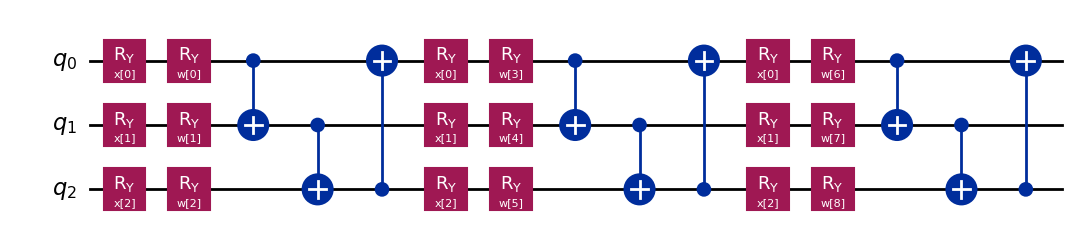

=== GLOBAL CIRCUIT (pre-transpile) ===


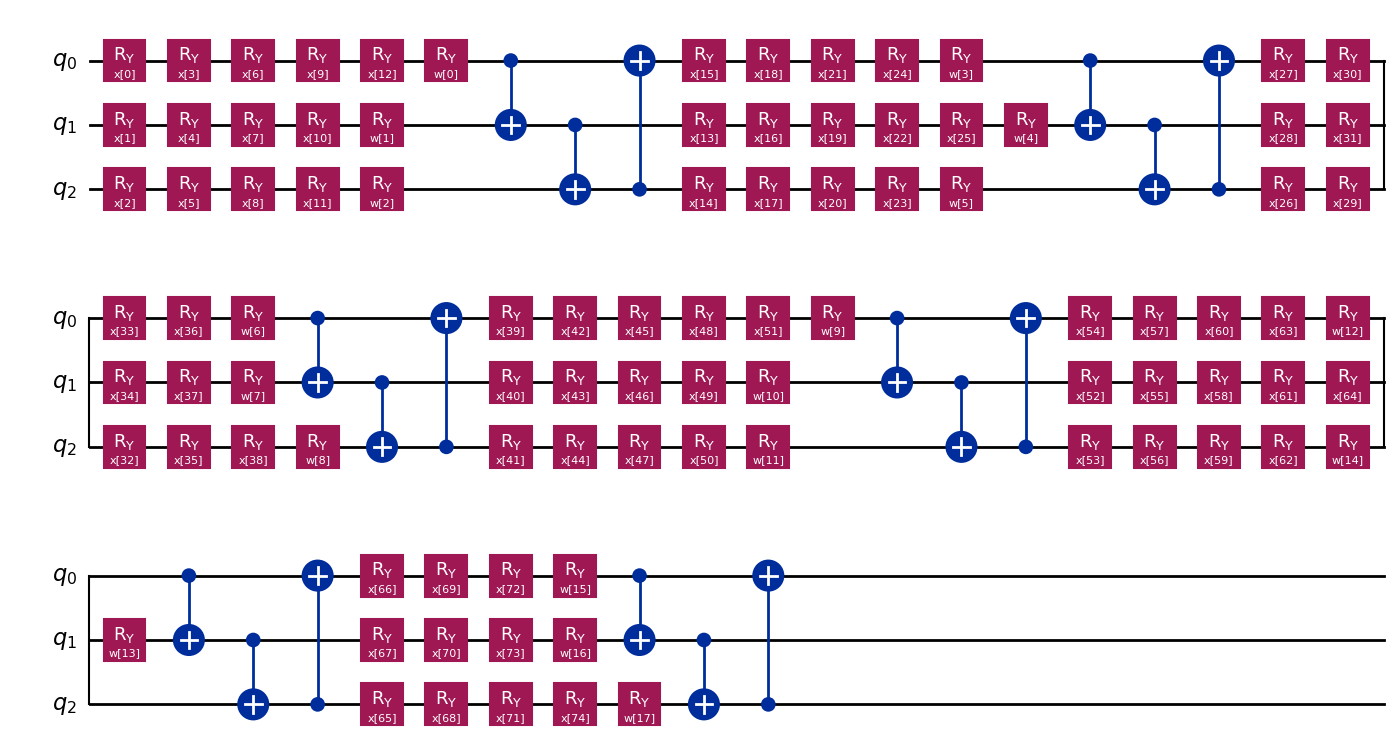

In [5]:
print('=== LOCAL CIRCUIT (pre-transpile) ===')
display(qc_local_raw.draw(output='mpl', style='iqp', fold=60))
print('=== GLOBAL CIRCUIT (pre-transpile) ===')
display(qc_global_raw.draw(output='mpl', style='iqp', fold=20))

## 5. Model

In [6]:
class QuantumConv(nn.Module):
    """
    Quanvolution — local circuit over 2x2 patches.
    Collects ALL patches from ALL samples, submits as ONE Aer job.
    Input : (B, N_QUBITS, Q_RES, Q_RES)
    Output: (B, Q_OUT, grid, grid)
    """
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(CFG.N_Q_LAYERS * CFG.N_QUBITS) * 0.01)

    def forward(self, x):
        B, C, H, W = x.shape
        x      = torch.tanh(x)
        q_out  = CFG.q_out()

        positions = [(i, j)
                     for i in range(0, H - 1, CFG.Q_STRIDE)
                     for j in range(0, W - 1, CFG.Q_STRIDE)]
        n_patches = len(positions)
        grid      = int(math.sqrt(n_patches))
        assert grid * grid == n_patches, (
            f'Non-square patch grid: {n_patches} patches. Adjust Q_RES/Q_STRIDE.')
        self.last_patch_count = n_patches

        all_patches = []
        for b in range(B):
            for (i, j) in positions:
                patch = x[b, :, i:i+2, j:j+2].reshape(-1)[:CFG.N_QUBITS]
                all_patches.append(patch)
        x_batch = torch.stack(all_patches)

        out = _LocalAerFn.apply(x_batch, self.weights)

        out = out.reshape(B, n_patches, q_out)
        out = out.permute(0, 2, 1)
        out = out.reshape(B, q_out, grid, grid)
        return out


class QuantumGlobal(nn.Module):
    """
    Global re-uploading encoder.
    Processes ALL samples in the batch in ONE Aer job.
    Input : (B, N_QUBITS, Q_RES, Q_RES)
    Output: (B, Q_OUT)
    """
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(CFG.N_Q_LAYERS_GLOBAL * CFG.N_QUBITS) * 0.01)

    def forward(self, x):
        B = x.shape[0]
        x = torch.tanh(x)
        x_batch = x.reshape(B, -1)[:, :CFG.n_inputs()]
        return _GlobalAerFn.apply(x_batch, self.weights)


class ClassicalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1,  16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())

    def forward(self, x):
        x1 = self.block1(x)
        x2 = self.block2(x1)
        x3 = self.block3(x2)
        return x1, x2, x3


class QCCNNParallel(nn.Module):
    """
    Tri-branch hybrid (all CPU):
      classical  -> GAP(x3)       : 64-d
      local  Q   -> spatial mean  : Q_OUT-d
      global Q   -> direct output : Q_OUT-d
    Cat -> FC -> 10 classes
    """
    def __init__(self):
        super().__init__()
        self.classical = ClassicalCNN()
        self.reduce    = nn.Conv2d(32, CFG.N_QUBITS, 1)
        self.q_local   = QuantumConv()
        self.q_global  = QuantumGlobal()
        fc_in = 64 + CFG.q_out() + CFG.q_out()
        self.fc = nn.Sequential(
            nn.Linear(fc_in, 64), nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        _, x2, x3 = self.classical(x)
        x2  = F.interpolate(x2, size=(CFG.Q_RES, CFG.Q_RES))
        red = self.reduce(x2)
        ql  = torch.mean(self.q_local(red),  dim=(2, 3))
        qg  = self.q_global(red)
        xc  = torch.mean(x3, dim=(2, 3))
        return self.fc(torch.cat([xc, ql, qg], dim=1))


model     = QCCNNParallel()
optimizer = torch.optim.Adam(model.parameters(), lr=CFG.LR)
loss_fn   = nn.CrossEntropyLoss()

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable params : {total:,}')
print(f'  Classical            : {sum(p.numel() for p in model.classical.parameters()):,}')
print(f'  Reduce               : {sum(p.numel() for p in model.reduce.parameters()):,}')
print(f'  Q local  weights     : {sum(p.numel() for p in model.q_local.parameters()):,}')
print(f'  Q global weights     : {sum(p.numel() for p in model.q_global.parameters()):,}')
print(f'  FC                   : {sum(p.numel() for p in model.fc.parameters()):,}')
print(f'  fc_in                : 64 + {CFG.q_out()} + {CFG.q_out()} = {64 + CFG.q_out()*2}')
print(f'Batch parallelism:')
n_p = len([(i,j) for i in range(0, CFG.Q_RES-1, CFG.Q_STRIDE)
                 for j in range(0, CFG.Q_RES-1, CFG.Q_STRIDE)])
print(f'  Local  pubs per fwd batch : {CFG.BATCH_SIZE} x {n_p} patches x {Q_OUT} obs = {CFG.BATCH_SIZE*n_p*Q_OUT}')
print(f'  Global pubs per fwd batch : {CFG.BATCH_SIZE} x {Q_OUT} obs = {CFG.BATCH_SIZE*Q_OUT}')
print(f'  Local  pubs per bwd batch : {CFG.BATCH_SIZE} x {n_p} x {CFG.N_Q_LAYERS*CFG.N_QUBITS} weights x 2 x {Q_OUT} = {CFG.BATCH_SIZE*n_p*CFG.N_Q_LAYERS*CFG.N_QUBITS*2*Q_OUT}')

Total trainable params : 29,384
  Classical            : 23,296
  Reduce               : 99
  Q local  weights     : 9
  Q global weights     : 18
  FC                   : 5,962
  fc_in                : 64 + 9 + 9 = 82
Batch parallelism:
  Local  pubs per fwd batch : 32 x 4 patches x 9 obs = 1152
  Global pubs per fwd batch : 32 x 9 obs = 288
  Local  pubs per bwd batch : 32 x 4 x 9 weights x 2 x 9 = 20736


## 6. Example Forward Pass

Label          : 2
Reduced shape  : torch.Size([1, 3, 5, 5])   (B, N_QUBITS, Q_RES, Q_RES)
Local Q shape  : torch.Size([1, 9, 2, 2])   (B, Q_OUT, grid, grid)
Global Q shape : torch.Size([1, 9])   (B, Q_OUT)


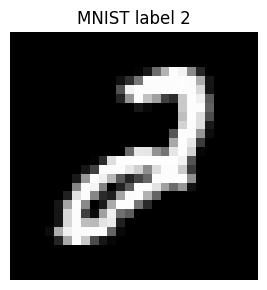

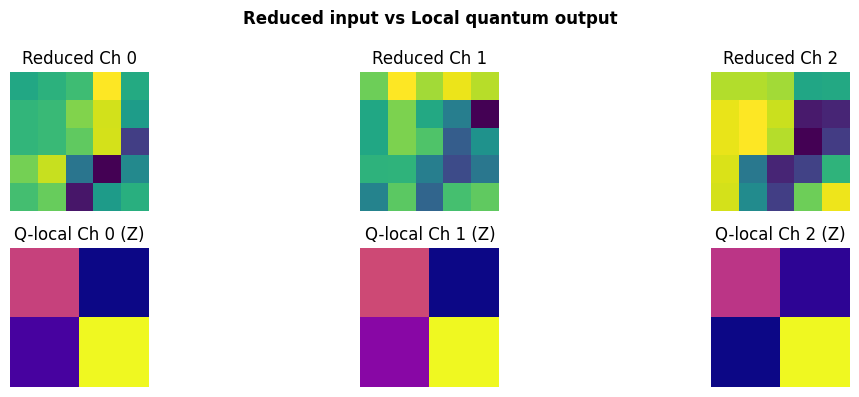

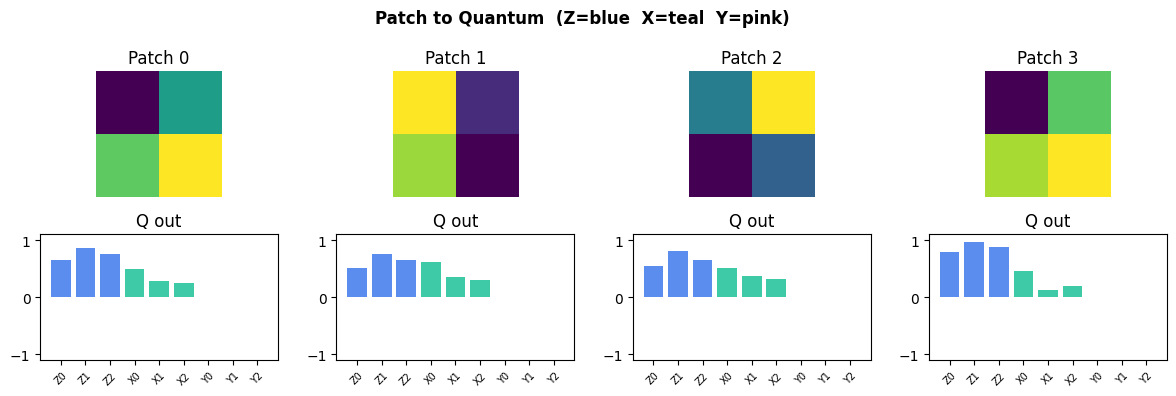

In [7]:
model.eval()
x_sample, y_sample = next(iter(train_loader))
x_one = x_sample[0:1]
label = y_sample[0].item()

with torch.no_grad():
    _, x2, x3 = model.classical(x_one)
    x2_r = F.interpolate(x2, size=(CFG.Q_RES, CFG.Q_RES))
    red  = model.reduce(x2_r)
    ql   = model.q_local(red)
    qg   = model.q_global(red)

print(f'Label          : {label}')
print(f'Reduced shape  : {red.shape}   (B, N_QUBITS, Q_RES, Q_RES)')
print(f'Local Q shape  : {ql.shape}   (B, Q_OUT, grid, grid)')
print(f'Global Q shape : {qg.shape}   (B, Q_OUT)')

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(x_one[0, 0].numpy(), cmap='gray')
ax.set_title(f'MNIST label {label}'); ax.axis('off')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, CFG.N_QUBITS, figsize=(4 * CFG.N_QUBITS, 4))
if CFG.N_QUBITS == 1:
    axes = axes.reshape(2, 1)
for i in range(CFG.N_QUBITS):
    axes[0, i].imshow(red[0, i].detach().numpy(), cmap='viridis')
    axes[0, i].set_title(f'Reduced Ch {i}'); axes[0, i].axis('off')
    axes[1, i].imshow(ql[0, i].detach().numpy(), cmap='plasma')
    axes[1, i].set_title(f'Q-local Ch {i} (Z)'); axes[1, i].axis('off')
plt.suptitle('Reduced input vs Local quantum output', fontweight='bold')
plt.tight_layout(); plt.show()

basis_labels = [f'Z{i}' for i in range(CFG.N_QUBITS)] + \
               [f'X{i}' for i in range(CFG.N_QUBITS)] + \
               [f'Y{i}' for i in range(CFG.N_QUBITS)]
bar_colors   = ['#5B8DEF']*CFG.N_QUBITS + ['#3EC9A7']*CFG.N_QUBITS + ['#E8668A']*CFG.N_QUBITS

n_show = 6
patches, q_outs = [], []
for i in range(0, CFG.Q_RES - 1, CFG.Q_STRIDE):
    for j in range(0, CFG.Q_RES - 1, CFG.Q_STRIDE):
        if len(patches) >= n_show: break
        p2d = red[0, 0, i:i+2, j:j+2]
        if p2d.numel() != 4: continue
        with torch.no_grad():
            q_out = run_local(p2d.reshape(-1)[:CFG.N_QUBITS], model.q_local.weights)
        patches.append(p2d.detach().numpy())
        q_outs.append(q_out.numpy())
    if len(patches) >= n_show: break

if patches:
    fig, axes = plt.subplots(2, len(patches), figsize=(3*len(patches), 4))
    if len(patches) == 1: axes = axes.reshape(2, 1)
    for k, (p, q) in enumerate(zip(patches, q_outs)):
        axes[0, k].imshow(p, cmap='viridis')
        axes[0, k].set_title(f'Patch {k}'); axes[0, k].axis('off')
        axes[1, k].bar(range(Q_OUT), q, color=bar_colors, edgecolor='none')
        axes[1, k].set_xticks(range(Q_OUT))
        axes[1, k].set_xticklabels(basis_labels, fontsize=7, rotation=45)
        axes[1, k].set_ylim(-1.1, 1.1)
        axes[1, k].set_title('Q out')
    plt.suptitle('Patch to Quantum  (Z=blue  X=teal  Y=pink)', fontweight='bold')
    plt.tight_layout(); plt.show()

## 7. Helper Functions

In [8]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            all_preds.extend(torch.argmax(out, 1).numpy())
            all_labels.extend(y.numpy())
            all_probs.extend(torch.softmax(out, 1).numpy())
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    probs  = np.array(all_probs)
    return {
        'acc'          : accuracy_score(labels, preds),
        'precision'    : precision_score(labels, preds, average='macro', zero_division=0),
        'recall'       : recall_score(labels, preds, average='macro', zero_division=0),
        'f1_macro'     : f1_score(labels, preds, average='macro'),
        'f1_micro'     : f1_score(labels, preds, average='micro'),
        'top3'         : top_k_accuracy_score(labels, probs, k=3),
        'top5'         : top_k_accuracy_score(labels, probs, k=5),
        'preds'        : preds,
        'labels'       : labels,
    }


def compute_contributions(model, loader):
    x, _ = next(iter(loader))
    with torch.no_grad():
        _, x2, x3 = model.classical(x)
        x2  = F.interpolate(x2, size=(CFG.Q_RES, CFG.Q_RES))
        red = model.reduce(x2)
        ql  = model.q_local(red)
        qg  = model.q_global(red)
    xc   = torch.mean(x3, dim=(2, 3))
    ql_m = torch.mean(ql, dim=(2, 3))
    xc_e  = torch.mean(xc**2).item()
    ql_e  = torch.mean(ql_m**2).item()
    qg_e  = torch.mean(qg**2).item()
    tot_e = xc_e + ql_e + qg_e + 1e-12
    c_p   = sum(p.numel() for p in model.classical.parameters())
    ql_p  = sum(p.numel() for p in model.q_local.parameters())
    qg_p  = sum(p.numel() for p in model.q_global.parameters())
    tot_p = c_p + ql_p + qg_p
    return {
        'param_classical': c_p  / tot_p,
        'param_local'    : ql_p / tot_p,
        'param_global'   : qg_p / tot_p,
        'feat_classical' : xc_e / tot_e,
        'feat_local'     : ql_e / tot_e,
        'feat_global'    : qg_e / tot_e,
    }



def evaluate_noisy(model, loader):
    """Evaluate using FakeFez noise. Swaps _estimator temporarily."""
    global _estimator
    _bak = _estimator
    _estimator = _noisy_estimator
    model.eval()
    preds, labels = [], []
    try:
        with torch.no_grad():
            for x, y in loader:
                out = model(x)
                preds.extend(torch.argmax(out, 1).numpy())
                labels.extend(y.numpy())
    finally:
        _estimator = _bak
    return accuracy_score(labels, preds)


print('Helpers defined.')

Helpers defined.


## 8. Training

In [9]:
best_acc = 0.0

with open(CFG.CSV_PATH, 'w', newline='') as f:
    csv.writer(f).writerow([
        'epoch', 'loss',
        'acc', 'precision', 'recall', 'f1_macro', 'f1_micro',
        'top3', 'top5',
        'param_local', 'param_global', 'param_classical',
        'feat_local', 'feat_global', 'feat_classical', 'feat_quantum_total',
        'noisy_acc', 'patch_count', 'val_time_s', 'noisy_val_time_s', 'epoch_time_s',
    ])

for epoch in range(CFG.EPOCHS):
    model.train()
    total_loss = 0.0
    t0 = time.time()

    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{CFG.EPOCHS}')
    for x, y in loop:
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        loop.set_postfix(loss=f'{loss.item():.4f}')

    t_val0 = time.time()
    metrics = evaluate(model, val_loader)
    val_time = time.time() - t_val0
    
    contrib = compute_contributions(model, val_loader)
    
    t_noisy0 = time.time()
    noisy_acc = evaluate_noisy(model, val_loader)
    noisy_val_time = time.time() - t_noisy0
    
    feat_q  = contrib['feat_local'] + contrib['feat_global']
    patch_count = getattr(model.q_local, 'last_patch_count', -1)
    epoch_time  = time.time() - t0

    print(f'\n{"="*35} EPOCH {epoch+1} {"="*35}')
    print(f'  Loss           : {total_loss:.4f}')
    print(f'  Acc            : {metrics["acc"]:.4f}')
    print(f'  Precision      : {metrics["precision"]:.4f}')
    print(f'  Recall         : {metrics["recall"]:.4f}')
    print(f'  F1 macro/micro : {metrics["f1_macro"]:.4f} / {metrics["f1_micro"]:.4f}')
    print(f'  Top-3 / Top-5  : {metrics["top3"]:.4f} / {metrics["top5"]:.4f}')
    print(f'  Noisy acc (FakeFez)  : {noisy_acc:.4f}')
    print(f'  Patches        : {patch_count}')
    print(f'  Clean Val Time : {val_time:.2f}s')
    print(f'  Noisy Val Time : {noisy_val_time:.2f}s')
    print(f'  Epoch Time     : {epoch_time:.2f}s')
    print(f'  Feat contrib  — classical: {contrib["feat_classical"]:.4f}  '
          f'local-Q: {contrib["feat_local"]:.4f}  global-Q: {contrib["feat_global"]:.4f}')

    if metrics['acc'] > best_acc:
        best_acc = metrics['acc']
        torch.save(model.state_dict(), CFG.MODEL_PATH)
        print(f'  checkmark Best model saved  (acc={best_acc:.4f})')

    with open(CFG.CSV_PATH, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch+1, total_loss,
            metrics['acc'], metrics['precision'], metrics['recall'],
            metrics['f1_macro'], metrics['f1_micro'],
            metrics['top3'], metrics['top5'],
            contrib['param_local'], contrib['param_global'], contrib['param_classical'],
            contrib['feat_local'], contrib['feat_global'], contrib['feat_classical'],
            feat_q, noisy_acc, patch_count, val_time, noisy_val_time, epoch_time,
        ])

print(f'\nTraining done. Best val acc: {best_acc:.4f}')

Epoch 1/5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [04:20<00:00,  8.14s/it, loss=2.2838]



=================================== EPOCH 1 ===================================
  Loss           : 73.5234
  Acc            : 0.1400
  Precision      : 0.0454
  Recall         : 0.1268
  F1 macro/micro : 0.0526 / 0.1400
  Top-3 / Top-5  : 0.4500 / 0.7300
  Noisy acc (FakeFez)  : 0.1400
  Patches        : 4
  Clean Val Time : 1.12s
  Noisy Val Time : 175.89s
  Epoch Time     : 437.83s
  Feat contrib  — classical: 0.0860  local-Q: 0.5433  global-Q: 0.3708
  checkmark Best model saved  (acc=0.1400)


Epoch 2/5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [03:25<00:00,  6.41s/it, loss=2.2241]



=================================== EPOCH 2 ===================================
  Loss           : 72.6980
  Acc            : 0.1900
  Precision      : 0.1969
  Recall         : 0.1839
  F1 macro/micro : 0.1166 / 0.1900
  Top-3 / Top-5  : 0.4600 / 0.7000
  Noisy acc (FakeFez)  : 0.1900
  Patches        : 4
  Clean Val Time : 0.99s
  Noisy Val Time : 161.31s
  Epoch Time     : 367.65s
  Feat contrib  — classical: 0.1284  local-Q: 0.5435  global-Q: 0.3282
  checkmark Best model saved  (acc=0.1900)


Epoch 3/5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [03:29<00:00,  6.55s/it, loss=2.2044]



=================================== EPOCH 3 ===================================
  Loss           : 71.7501
  Acc            : 0.2200
  Precision      : 0.0770
  Recall         : 0.1645
  F1 macro/micro : 0.0930 / 0.2200
  Top-3 / Top-5  : 0.4400 / 0.6800
  Noisy acc (FakeFez)  : 0.2200
  Patches        : 4
  Clean Val Time : 0.99s
  Noisy Val Time : 165.66s
  Epoch Time     : 376.67s
  Feat contrib  — classical: 0.4958  local-Q: 0.2937  global-Q: 0.2105
  checkmark Best model saved  (acc=0.2200)


Epoch 4/5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [03:44<00:00,  7.00s/it, loss=1.8039]



=================================== EPOCH 4 ===================================
  Loss           : 68.2939
  Acc            : 0.2700
  Precision      : 0.1004
  Recall         : 0.2362
  F1 macro/micro : 0.1330 / 0.2700
  Top-3 / Top-5  : 0.5200 / 0.7300
  Noisy acc (FakeFez)  : 0.2700
  Patches        : 4
  Clean Val Time : 0.99s
  Noisy Val Time : 167.03s
  Epoch Time     : 392.47s
  Feat contrib  — classical: 0.7402  local-Q: 0.1537  global-Q: 0.1061
  checkmark Best model saved  (acc=0.2700)


Epoch 5/5: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [03:40<00:00,  6.90s/it, loss=1.9829]



=================================== EPOCH 5 ===================================
  Loss           : 63.8233
  Acc            : 0.2900
  Precision      : 0.1610
  Recall         : 0.2485
  F1 macro/micro : 0.1605 / 0.2900
  Top-3 / Top-5  : 0.6200 / 0.7600
  Noisy acc (FakeFez)  : 0.2900
  Patches        : 4
  Clean Val Time : 1.04s
  Noisy Val Time : 172.41s
  Epoch Time     : 394.46s
  Feat contrib  — classical: 0.8300  local-Q: 0.1017  global-Q: 0.0683
  checkmark Best model saved  (acc=0.2900)

Training done. Best val acc: 0.2900


## 9. Test — Load Best Model

In [10]:
model_test = QCCNNParallel()
state = torch.load(CFG.MODEL_PATH, map_location='cpu')
state = {k: v for k, v in state.items()
         if 'total_ops' not in k and 'total_params' not in k}
model_test.load_state_dict(state)
model_test.eval()

m = evaluate(model_test, val_loader)
print('===== BEST MODEL =====')
print(f'  Acc           : {m["acc"]:.4f}')
print(f'  Precision     : {m["precision"]:.4f}')
print(f'  Recall        : {m["recall"]:.4f}')
print(f'  F1 macro/micro: {m["f1_macro"]:.4f} / {m["f1_micro"]:.4f}')
print(f'  Top-3 / Top-5 : {m["top3"]:.4f} / {m["top5"]:.4f}')

===== BEST MODEL =====
  Acc           : 0.2900
  Precision     : 0.1610
  Recall        : 0.2485
  F1 macro/micro: 0.1605 / 0.2900
  Top-3 / Top-5 : 0.6200 / 0.7600


## 10. Confusion Matrix

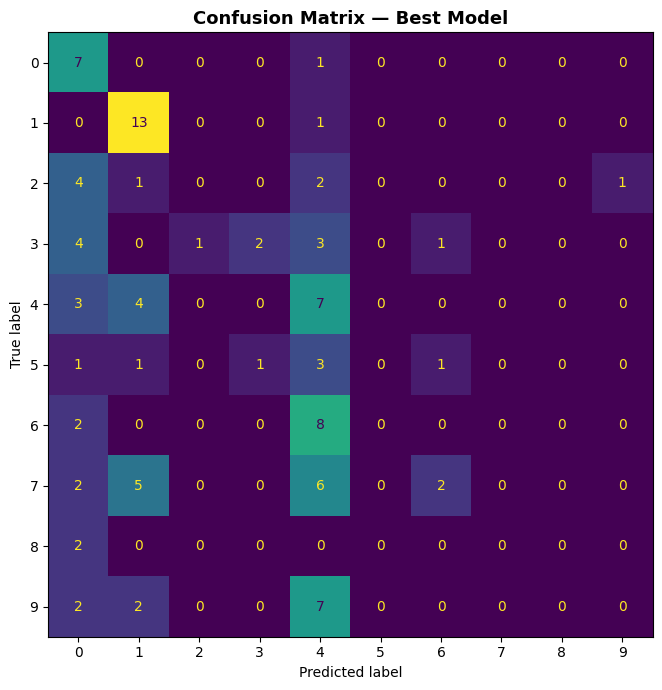

In [11]:
cm = confusion_matrix(m['labels'], m['preds'])
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Best Model', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

## 11. Training Curves

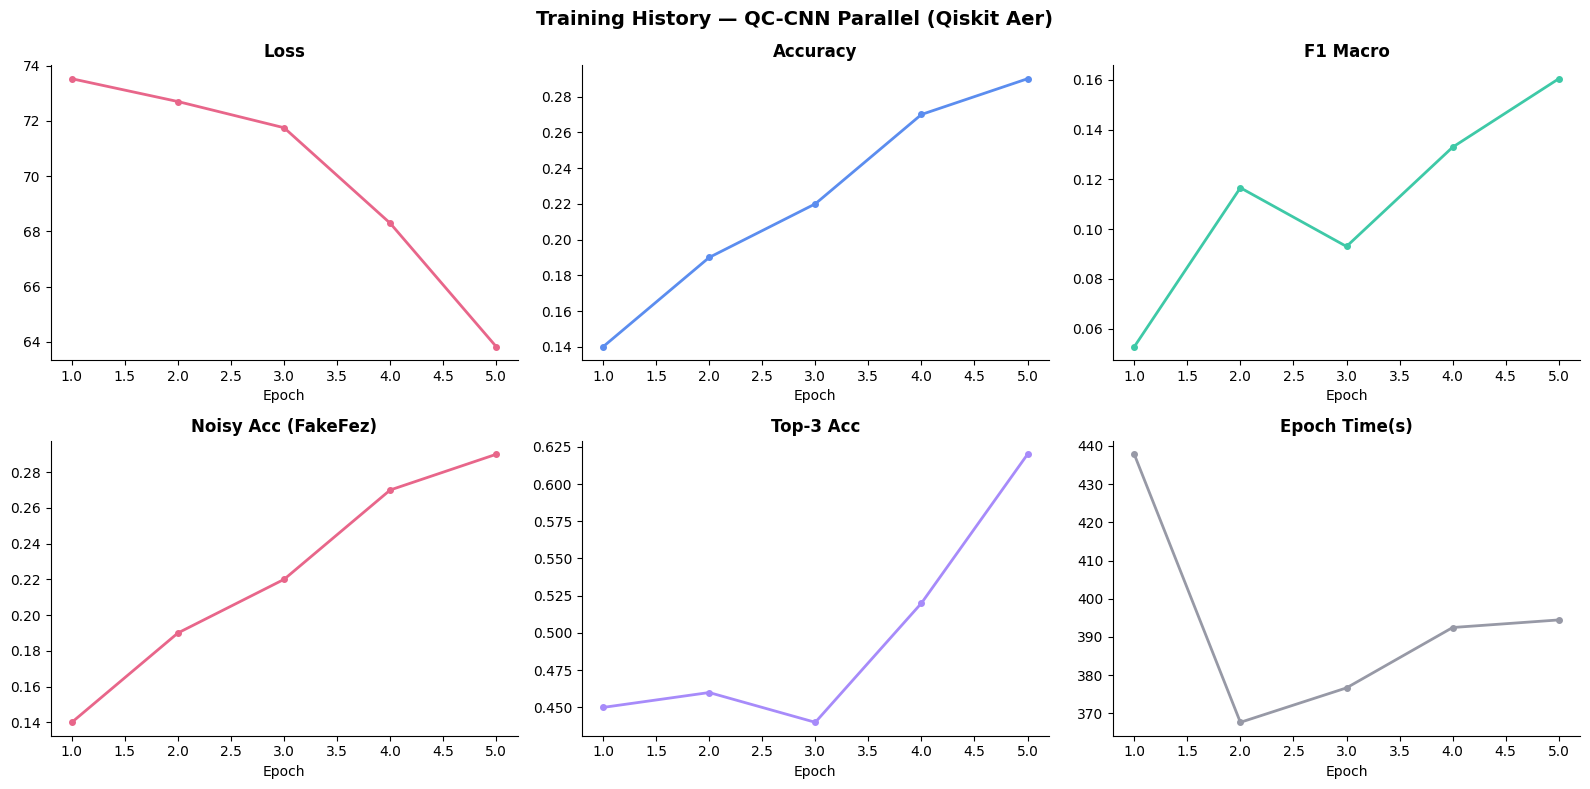

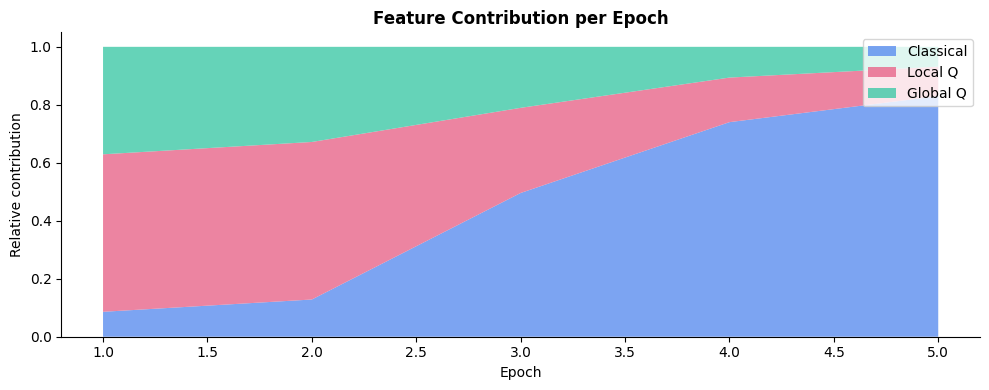

In [12]:
import pandas as pd
log = pd.read_csv(CFG.CSV_PATH)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Training History — QC-CNN Parallel (Qiskit Aer)',
             fontsize=14, fontweight='bold')
plots = [
    (axes[0,0], 'loss',         'Loss',         '#E8668A'),
    (axes[0,1], 'acc',          'Accuracy',     '#5B8DEF'),
    (axes[0,2], 'f1_macro',     'F1 Macro',     '#3EC9A7'),
    (axes[1,0], 'noisy_acc',   'Noisy Acc (FakeFez)', '#E8668A'),
    (axes[1,1], 'top3',         'Top-3 Acc',    '#A78BFA'),
    (axes[1,2], 'epoch_time_s', 'Epoch Time(s)','#9799A6'),
]
for ax, col, title, color in plots:
    ax.plot(log['epoch'], log[col], color=color, linewidth=2, marker='o', markersize=4)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.stackplot(log['epoch'],
             log['feat_classical'], log['feat_local'], log['feat_global'],
             labels=['Classical', 'Local Q', 'Global Q'],
             colors=['#5B8DEF', '#E8668A', '#3EC9A7'], alpha=0.8)
ax.set_title('Feature Contribution per Epoch', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Relative contribution')
ax.legend(loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()